In [1]:
# ==========================================
# Cell 1 - Import Libraries
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# ==========================================
# Cell 2 - Load Cleaned Dataset
# ==========================================

df = pd.read_csv("../data/processed/Nassau_Candy_Cleaned.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [3]:
# ==========================================
# Cell 3 - Dataset Shape
# ==========================================

print(f"Rows : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Rows : 10194
Columns : 25


In [4]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost,Raw Lead Time (Unreliable),Lead Time (Days),Corrected Ship Date,Factory,Route State,Route Region,Delayed
0,1,US-2021-103800-CHO-MIL-31000,2024-01-03,2026-06-30,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28,909,6,2024-01-09,Wicked Choccy's,Wicked Choccy's → Texas,Wicked Choccy's → Interior,True
1,2,US-2021-112326-CHO-TRI-54000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60,909,7,2024-01-11,Wicked Choccy's,Wicked Choccy's → Illinois,Wicked Choccy's → Interior,True
2,3,US-2021-112326-CHO-NUT-13000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00,909,4,2024-01-08,Lot's O' Nuts,Lot's O' Nuts → Illinois,Lot's O' Nuts → Interior,False
3,4,US-2021-112326-CHO-SCR-58000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30,909,6,2024-01-10,Lot's O' Nuts,Lot's O' Nuts → Illinois,Lot's O' Nuts → Interior,True
4,5,US-2021-141817-CHO-TRI-54000,2024-01-05,2026-07-05,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90,912,6,2024-01-11,Wicked Choccy's,Wicked Choccy's → Pennsylvania,Wicked Choccy's → Atlantic,True


In [5]:
# ==========================================
# Cell 5 - Total Sales
# ==========================================

total_sales = df["Sales"].sum()

print(f"Total Sales: ${total_sales:,.2f}")

Total Sales: $141,783.63


In [6]:
# ==========================================
# Cell 6 - Total Gross Profit
# ==========================================

total_profit = df["Gross Profit"].sum()

print(f"Total Gross Profit: ${total_profit:,.2f}")

Total Gross Profit: $93,442.80


In [7]:
# ==========================================
# Cell 7 - Average Lead Time (raw, diagnostic)
# ==========================================

# This uses the RAW (corrupted) Ship Date column, kept here only to document
# the data quality issue found below. The real analysis uses 'Lead Time (Days)'.
avg_lead_raw = df["Raw Lead Time (Unreliable)"].mean()

print(f"Average Raw Lead Time: {avg_lead_raw:.2f} days  <- clearly unrealistic")

Average Raw Lead Time: 1320.84 days  <- clearly unrealistic


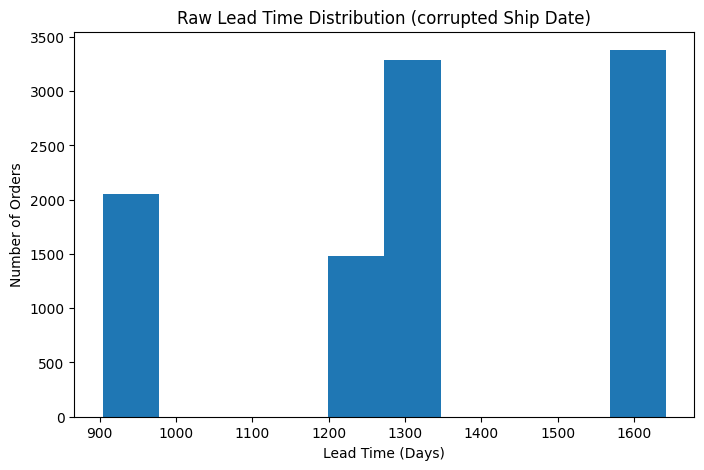

In [8]:
# ==========================================
# Cell 8 - Raw Lead Time Distribution (diagnostic)
# ==========================================

plt.figure(figsize=(8,5))
plt.hist(df["Raw Lead Time (Unreliable)"], bins=10)
plt.title("Raw Lead Time Distribution (corrupted Ship Date)")
plt.xlabel("Lead Time (Days)")
plt.ylabel("Number of Orders")
plt.show()

## Observation

- The raw lead time is clustered around 900-1,600+ days, which is not physically plausible for candy shipping.
- This confirms the `Ship Date` column is corrupted and cannot be used directly - see the correction applied in notebook 02, loaded below as `Lead Time (Days)`.

In [9]:
# ==========================================
# Cell 9 - Check Date Range
# ==========================================

print("Order Date Range")
print(df["Order Date"].min())
print(df["Order Date"].max())

print("\nShip Date Range")
print(df["Ship Date"].min())
print(df["Ship Date"].max())

Order Date Range
2024-01-02
2025-12-31

Ship Date Range
2026-06-30
2030-06-28


In [10]:
# ==========================================
# Cell 10 - Raw Lead Time Statistics (diagnostic)
# ==========================================

df["Raw Lead Time (Unreliable)"].describe()

count    10194.000000
mean      1320.841868
std        262.444892
min        904.000000
25%       1271.000000
50%       1274.000000
75%       1638.000000
max       1642.000000
Name: Raw Lead Time (Unreliable), dtype: float64

In [11]:
# Show the raw date strings from the CSV
raw_df = pd.read_csv("../data/Nassau_Candy_Distributor.csv")

raw_df[["Order Date", "Ship Date"]].head(20)

,Order Date,Ship Date
0,03-01-2024,30-06-2026
1,04-01-2024,01-07-2026
2,04-01-2024,01-07-2026
3,04-01-2024,01-07-2026
4,05-01-2024,05-07-2026
5,06-01-2024,03-07-2026
6,06-01-2024,03-07-2026
7,06-01-2024,30-06-2026
8,06-01-2024,03-07-2026
9,06-01-2024,03-07-2026


In [12]:
# Show a few unique dates
print(raw_df["Order Date"].head(10).tolist())
print(raw_df["Ship Date"].head(10).tolist())

['03-01-2024', '04-01-2024', '04-01-2024', '04-01-2024', '05-01-2024', '06-01-2024', '06-01-2024', '06-01-2024', '06-01-2024', '06-01-2024']
['30-06-2026', '01-07-2026', '01-07-2026', '01-07-2026', '05-07-2026', '03-07-2026', '03-07-2026', '30-06-2026', '03-07-2026', '03-07-2026']


In [13]:
df[["Order Date", "Ship Date", "Raw Lead Time (Unreliable)"]].head(10)

,Order Date,Ship Date,Raw Lead Time (Unreliable)
0,2024-01-03,2026-06-30,909
1,2024-01-04,2026-07-01,909
2,2024-01-04,2026-07-01,909
3,2024-01-04,2026-07-01,909
4,2024-01-05,2026-07-05,912
5,2024-01-06,2026-07-03,909
6,2024-01-06,2026-07-03,909
7,2024-01-06,2026-06-30,906
8,2024-01-06,2026-07-03,909
9,2024-01-06,2026-07-03,909


In [14]:
df["Ship Mode"].value_counts()

Ship Mode
Standard Class    6120
Second Class      1979
First Class       1548
Same Day           547
Name: count, dtype: int64

## Corrected Lead Time

The `Lead Time (Days)` and `Corrected Ship Date` columns were generated in notebook `02_Data_Cleaning_Feature_Engineering.ipynb` (simulated from `Ship Mode`, since the raw `Ship Date` could not be trusted - see diagnosis above) and are already present in the cleaned dataset loaded at the top of this notebook. **All analysis from here on uses `Lead Time (Days)`.**

> ⚠️ Limitation: because this field is derived from `Ship Mode` alone, treat lead-time comparisons across routes/regions as reflecting ship-mode mix, not independently observed delivery performance.

In [15]:
# ==========================================
# Corrected Lead Time - Summary Stats
# ==========================================

print(df["Lead Time (Days)"].describe())
print("\nNegative corrected lead times:", (df["Lead Time (Days)"] < 0).sum())

count    10194.000000
mean         4.110457
std          2.067905
min          0.000000
25%          2.000000
50%          4.000000
75%          6.000000
max          7.000000
Name: Lead Time (Days), dtype: float64

Negative corrected lead times: 0


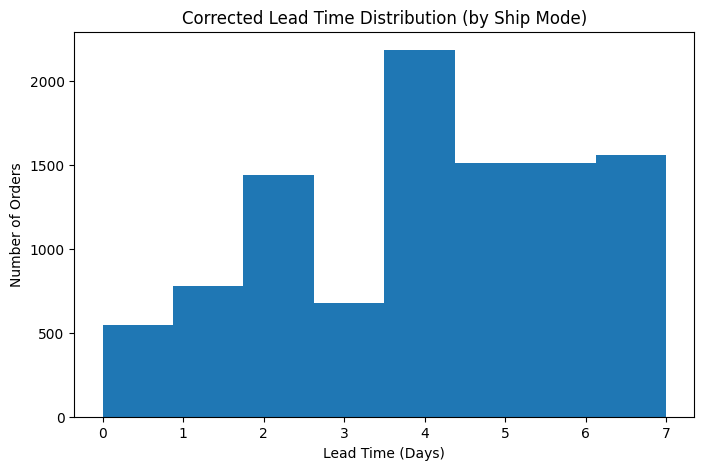

In [16]:
# ==========================================
# Corrected Lead Time Distribution
# ==========================================

plt.figure(figsize=(8,5))
plt.hist(df["Lead Time (Days)"], bins=8)
plt.title("Corrected Lead Time Distribution (by Ship Mode)")
plt.xlabel("Lead Time (Days)")
plt.ylabel("Number of Orders")
plt.show()